# ***Import Libaries & Load Dataset***

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet("cleaned/all_days.parquet")
df.head()

,date,segmentId,frc,speedLimit,distance,timeSet,hour,probeCount
0,2024-08-11,-13560111507837,6,45,20.87,2,0,4
1,2024-08-11,-13560111507837,6,45,20.87,3,1,2
2,2024-08-11,-13560111507837,6,45,20.87,4,2,1
3,2024-08-11,-13560111507837,6,45,20.87,5,3,0
4,2024-08-11,-13560111507837,6,45,20.87,6,4,0


# ***EDA***

In [3]:
df.shape

(11970240, 8)

In [4]:
df.isnull().sum()

date          0
segmentId     0
frc           0
speedLimit    0
distance      0
timeSet       0
hour          0
probeCount    0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11970240 entries, 0 to 11970239
Data columns (total 8 columns):
 #   Column      Dtype  
---  ------      -----  
 0   date        object 
 1   segmentId   int64  
 2   frc         int64  
 3   speedLimit  int64  
 4   distance    float64
 5   timeSet     int64  
 6   hour        int64  
 7   probeCount  int64  
dtypes: float64(1), int64(6), object(1)
memory usage: 730.6+ MB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,segmentId,frc,speedLimit,distance,timeSet,hour,probeCount
count,1.197024e+07,1.197024e+07,1.197024e+07,1.197024e+07,1.197024e+07,1.197024e+07,1.197024e+07
mean,7.338541e+12,3.609993e+00,4.752751e+01,5.629097e+01,1.350000e+01,1.150000e+01,1.240317e+02
std,1.140286e+13,1.604674e+00,8.156442e+00,6.895495e+01,6.922187e+00,6.922187e+00,1.962645e+02
min,-1.356035e+13,1.000000e+00,1.800000e+01,3.500000e+00,2.000000e+00,0.000000e+00,0.000000e+00
25%,1.356011e+13,2.000000e+00,4.500000e+01,1.527000e+01,7.750000e+00,5.750000e+00,9.000000e+00
50%,1.356014e+13,4.000000e+00,5.000000e+01,3.414000e+01,1.350000e+01,1.150000e+01,4.600000e+01
75%,1.356024e+13,5.000000e+00,5.000000e+01,7.059000e+01,1.925000e+01,1.725000e+01,1.480000e+02
max,1.356035e+13,6.000000e+00,8.000000e+01,1.353770e+03,2.500000e+01,2.300000e+01,2.766000e+03


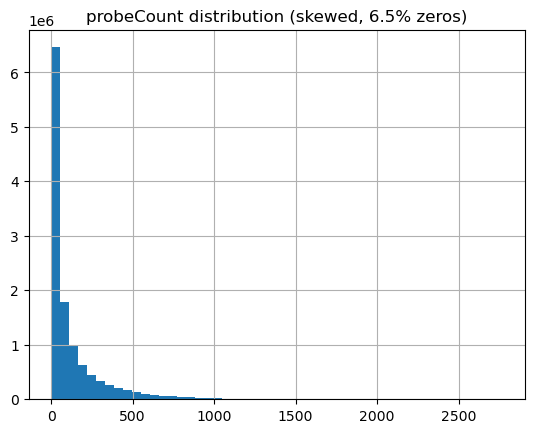

In [8]:
# Distribution of the target: heavily right-skewed with many 0s.
# That is why we later build normalized targets (probe_density, congestion_ratio) instead of raw counts
df["probeCount"].hist(bins=50)
plt.title("probeCount distribution (skewed, 6.5% zeros)")
plt.show()


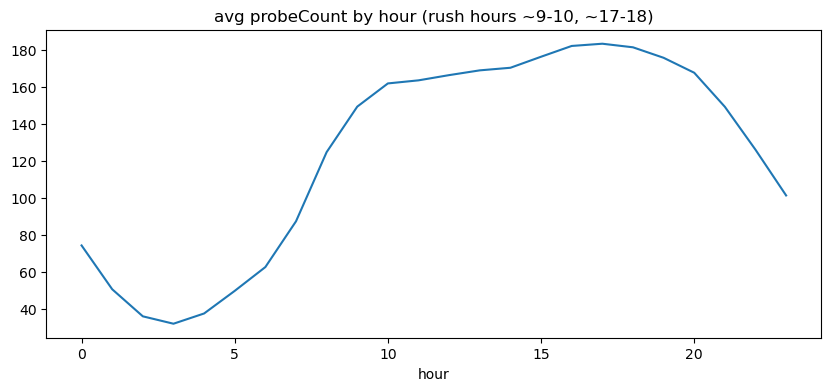

In [9]:
# Average traffic per hour -> confirms the rush hours (~9-10 and ~17-18).
# Proves 'hour' is a key predictor and motivates the cyclic hour_sin/hour_cos encoding
df.groupby("hour")["probeCount"].mean().plot(figsize=(10, 4),
                                            title="avg probeCount by hour (rush hours ~9-10, ~17-18)")
plt.show()


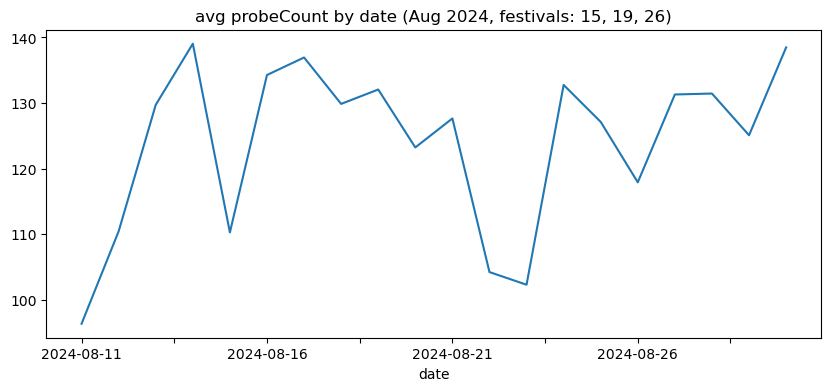

In [10]:
# Traffic per day -> festival days (15=Independence Day, 19=Rakshabandhan, 26=Janmashtami)
# behave differently from normal days, so we will create a 'festival' flag feature
df.groupby("date")["probeCount"].mean().plot(figsize=(10, 4),
                                             title="avg probeCount by date (Aug 2024, festivals: 15, 19, 26)")
plt.show()


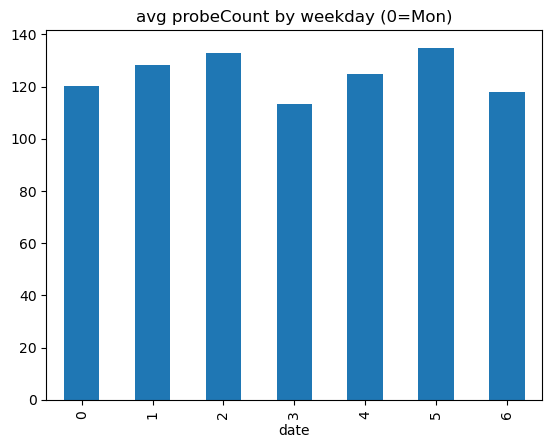

In [11]:
# Weekday pattern: Saturday is busiest, Sunday is quietest
# -> motivates the is_weekend flag so the model can treat weekends differently
df.groupby(pd.to_datetime(df["date"]).dt.dayofweek)["probeCount"].mean()\
  .plot(kind="bar", title="avg probeCount by weekday (0=Mon)")
plt.show()


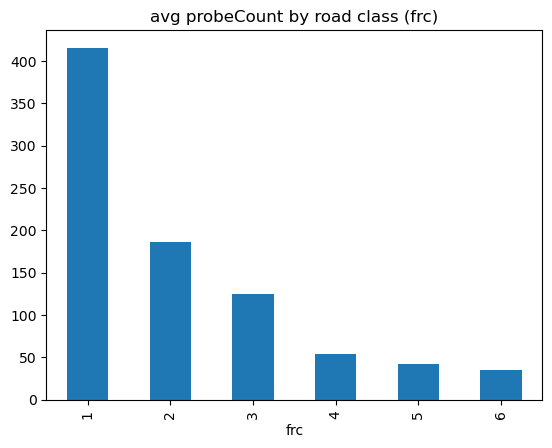

In [12]:
# Road class vs traffic: frc=1 (highways) is far busier than frc=6 (small streets).
# Road class strongly drives probeCount, so it must stay as a feature
df.groupby("frc")["probeCount"].mean().plot(kind="bar", title="avg probeCount by road class (frc)")
plt.show()


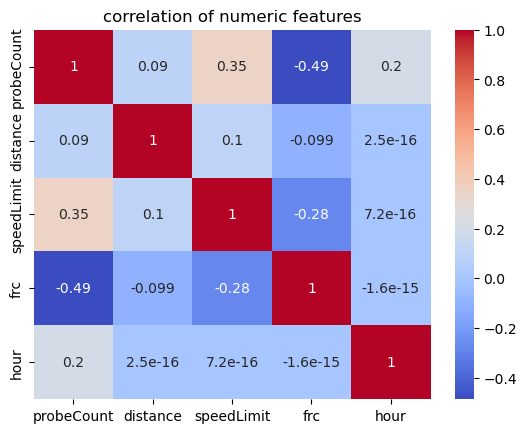

In [13]:
# Correlations: frc = -0.49 vs probeCount (strong), distance weak.
# Confirms no redundant numeric columns and shows which features actually matter
sns.heatmap(df[["probeCount", "distance", "speedLimit", "frc", "hour"]].corr(), annot=True, cmap="coolwarm")
plt.title("correlation of numeric features")
plt.show()


In [14]:
# Busiest segments: these are the roads that will dominate the routing graph
# and the ones our congestion predictions matter most for
print("top 10 busiest segments:")
print(df.groupby("segmentId")["probeCount"].mean().sort_values(ascending=False).head(10))


top 10 busiest segments:
segmentId
-13560179880493    1462.366667
 13560128348534    1458.195833
 13560128348526    1457.035417
-13560135311099    1454.491667
-13560330998374    1452.754167
-13560330997827    1452.254167
-13560135311090    1452.008333
-13560135311098    1444.802083
 13560344590551    1196.454167
 13560331074507    1189.356250
Name: probeCount, dtype: float64


In [15]:
df["probe_density"] = df["probeCount"] / df["distance"]

In [16]:
col = ['probeCount', 'distance', 'speedLimit', 'probe_density']

feature = df[col]

Q1 = feature.quantile(0.25)
Q3 = feature.quantile(0.75)

IQR = Q3-Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [17]:
outliers = ((feature < lower_bound) | (feature > upper_bound)).sum()
print("outliers per column:\n", outliers)

outliers per column:
 probeCount       1187829
distance          854400
speedLimit       1514400
probe_density    1495887
dtype: int64


# ***Data Cleaning***

In [18]:
df_cleaned = df.copy()

In [19]:
# Keep only valid rows: probeCount >= 0 and distance > 0 (a segment with no length is unusable)
df_cleaned = df[(df["probeCount"] >= 0) & (df["distance"] > 0)]


In [20]:
# segmentId must stay exact (int64): it identifies each road and is used
# for grouping and later for mapping onto the routing graph
df_cleaned["segmentId"] = df_cleaned["segmentId"].astype("int64")


In [21]:
# Downcast frc (road class, values 1-8) to int8: same values, less RAM
df_cleaned["frc"] = df_cleaned["frc"].astype("int8")


In [22]:
# Downcast hour (0-23) to int8: fits easily, halves memory vs int64
df_cleaned["hour"] = df_cleaned["hour"].astype("int8")


In [23]:
# speedLimit -> float32: 4 bytes instead of 8. With 12M rows this saves ~50MB per column
df_cleaned["speedLimit"] = df_cleaned["speedLimit"].astype("float32")


In [24]:
# distance -> float32 (same memory-saving reason)
df_cleaned["distance"] = df_cleaned["distance"].astype("float32")


In [25]:
# probeCount -> int32: max observed is 2766, so int32 is safe and memory is halved
df_cleaned["probeCount"] = df_cleaned["probeCount"].astype("int32")


In [26]:
# Verify: row count unchanged (nothing was dropped), but memory usage dropped ~4x
print("shape after cleaning:", df_cleaned.shape)
print("nulls:\n", df_cleaned.isna().sum())


shape after cleaning: (11970240, 9)
nulls:
 date             0
segmentId        0
frc              0
speedLimit       0
distance         0
timeSet          0
hour             0
probeCount       0
probe_density    0
dtype: int64


In [27]:
# Visual sanity check of the cleaned frame
df_cleaned.head()


,date,segmentId,frc,speedLimit,distance,timeSet,hour,probeCount,probe_density
0,2024-08-11,-13560111507837,6,45.0,20.870001,2,0,4,0.191663
1,2024-08-11,-13560111507837,6,45.0,20.870001,3,1,2,0.095831
2,2024-08-11,-13560111507837,6,45.0,20.870001,4,2,1,0.047916
3,2024-08-11,-13560111507837,6,45.0,20.870001,5,3,0,0.000000
4,2024-08-11,-13560111507837,6,45.0,20.870001,6,4,0,0.000000


* ***Skewness***

In [28]:
num_col = df_cleaned.select_dtypes(include="number")

num_col.skew()

segmentId       -1.287142
frc              0.080801
speedLimit      -0.456458
distance         3.913869
timeSet          0.000000
hour             0.000000
probeCount       3.048669
probe_density    7.307896
dtype: float64

In [29]:
# Fix right-skewed features (needed if we use linear models in the comparison):
# distance -> log (always positive), probeCount -> log1p (log1p handles the 6.5% zero rows)


# df_cleaned["distance_log"] = np.log(df_cleaned["distance"]).astype("float32")
# df_cleaned["probeCount_log"] = np.log1p(df_cleaned["probeCount"]).astype("float32")


In [30]:
# Verify the fix: skew should drop from ~3.9 / ~3.0 down to near 0

# print("distance   skew:", round(df_cleaned["distance"].skew(), 3), "->", round(df_cleaned["distance_log"].skew(), 3))
# print("probeCount skew:", round(df_cleaned["probeCount"].skew(), 3), "->", round(df_cleaned["probeCount_log"].skew(), 3))

# ***Feature Engineering***

In [31]:
# Convert date strings to datetime so we can extract calendar features from them
d = pd.to_datetime(df_cleaned["date"])

In [32]:
# dayofweek (0=Mon..6=Sun): traffic differs by weekday, the model needs to know it
df_cleaned["dayofweek"] = d.dt.dayofweek.astype("int8")


In [33]:
# Weekend flag: Saturdays/Sundays have an opposite pattern vs weekdays
# (seen in EDA), so a single 0/1 flag captures this
df_cleaned["is_weekend"] = (df_cleaned["dayofweek"] >= 5).astype("int8")


In [34]:
# Festival flag: Independence Day (15), Rakshabandhan (19), Janmashtami (26)
# change traffic; without this the model would treat them as ordinary days
df_cleaned["festival"] = df_cleaned["date"].isin(["2024-08-15", "2024-08-19", "2024-08-26"]).astype("int8")


In [35]:
# hour as sin: 23:00 and 00:00 are 1 hour apart in reality, but raw numbers 23 and 0 look far apart.
# sin/cos encoding makes hour a circle, so the model sees time correctly
df_cleaned["hour_sin"] = np.sin(2 * np.pi * df_cleaned["hour"] / 24).astype("float32")


In [36]:
# hour as cos: together with sin it uniquely describes the time of day (circle coordinates)
df_cleaned["hour_cos"] = np.cos(2 * np.pi * df_cleaned["hour"] / 24).astype("float32")


In [37]:
# Normalize by segment length: a 2km highway always has more GPS devices than a 50m lane,
# even with identical traffic. probe_density = devices per km makes roads comparable
df_cleaned["probe_density"] = (df_cleaned["probeCount"] / df_cleaned["distance"]).astype("float32")


In [38]:
# Per-segment baseline stats (median & mean density over TRAIN days only):
# tells the model whether this road is usually busy or quiet. Computed on
# Aug 11-24 only so val/test values never leak into these features
seg_train_dates = [f"2024-08-{d:02d}" for d in range(11, 25)]
seg_stats = df_cleaned[df_cleaned["date"].isin(seg_train_dates)].groupby("segmentId")["probe_density"].agg(median="median", mean="mean")


In [39]:
# Attach each segment's baseline stats to every row of that segment
df_cleaned = df_cleaned.merge(seg_stats, on="segmentId", how="left")


In [40]:
# Global fallback median: used when a segment's baseline is 0, to avoid division by zero
global_med = df_cleaned["median"].median()


In [41]:
# THE TARGET: how busy this road is vs its own usual self (1.0 = normal, 2.0 = twice as busy).
# Being normalized per segment, it is directly usable as the travel-time weight
# for the routing graph (Dijkstra/A*) later
df_cleaned["congestion_ratio"] = (df_cleaned["probe_density"] / df_cleaned["median"].replace(0, global_med)).astype("float32")


In [42]:
# Give the baseline columns clear, descriptive names
df_cleaned = df_cleaned.rename(columns={"median": "segment_median_density", "mean": "segment_avg_density"})


In [43]:
# Sort by time WITHIN each segment - required so that lag features
# (prev_day, prev_week) point at the correct earlier rows of the same road
df_cleaned = df_cleaned.sort_values(["segmentId", "date", "hour"]).reset_index(drop=True)


In [44]:
# Group by segmentId so every shift/rolling computation stays inside one road
grp = df_cleaned.groupby("segmentId")["probe_density"]


In [45]:
# Same hour YESTERDAY: traffic repeats daily, so yesterday's density is
# the strongest predictor of today (24 rows back = 24 hours back)
df_cleaned["prev_day_density"] = grp.shift(24).astype("float32")


In [46]:
# Same hour 7 days ago (same weekday): captures the weekly rhythm, e.g. Monday vs Sunday
df_cleaned["prev_week_density"] = grp.shift(24 * 7).astype("float32")


In [47]:
# Rolling 3-hour mean of PAST hours only: shifted by 1 row inside each segment
# so the current hour's density (the numerator of the target) is excluded
df_cleaned["rolling_3h_mean"] = grp.rolling(3, min_periods=1).mean().groupby(level=0).shift(1).astype("float32").values


In [48]:
# timeSet is just hour+2 (the raw hour label of each ticket) - redundant with 'hour', so drop it
df_cleaned = df_cleaned.drop(columns=["timeSet"])


In [49]:
# Sanity check: 19 columns, all new features created
print("final shape:", df_cleaned.shape)
print("columns:\n", df_cleaned.columns.tolist())
print("nulls:\n", df_cleaned.isna().sum())


final shape: (11970240, 19)
columns:
 ['date', 'segmentId', 'frc', 'speedLimit', 'distance', 'hour', 'probeCount', 'probe_density', 'dayofweek', 'is_weekend', 'festival', 'hour_sin', 'hour_cos', 'segment_median_density', 'segment_avg_density', 'congestion_ratio', 'prev_day_density', 'prev_week_density', 'rolling_3h_mean']
nulls:
 date                            0
segmentId                       0
frc                             0
speedLimit                      0
distance                        0
hour                            0
probeCount                      0
probe_density                   0
dayofweek                       0
is_weekend                      0
festival                        0
hour_sin                        0
hour_cos                        0
segment_median_density          0
segment_avg_density             0
congestion_ratio                0
prev_day_density           598512
prev_week_density         4189584
rolling_3h_mean             24938
dtype: int64


In [50]:
df_final = df_cleaned.copy()

In [51]:
# The first 7 days have no '7 days ago' -> NaN. Fill with the segment's own median density
# (a neutral 'usual traffic' guess), so no row is skipped by the model
df_final["prev_week_density"] = df_final["prev_week_density"].fillna(df_final["segment_median_density"])


In [52]:
# The first day has no 'yesterday' -> NaN. Same neutral fill with the segment median
df_final["prev_day_density"] = df_final["prev_day_density"].fillna(df_final["segment_median_density"])


In [53]:
# rolling_3h_mean is NaN for the first hour of each segment (24938 rows, no past history).
# Fill with the segment's own median density - the same neutral 'usual traffic' guess
# used for prev_day/prev_week - so no row is dropped and the model sees consistent features
df_final["rolling_3h_mean"] = df_final["rolling_3h_mean"].fillna(df_final["segment_median_density"])

In [54]:
# Keep date for the time-based split, then remove it from the model frame
# (date itself is never a feature - calendar features already exist)
dates = df_final["date"].copy()
df_final = df_final.drop(columns="date", axis=1)


In [55]:
# Save the final ML-ready dataset once, so this heavy step never needs recomputing
df_final.to_parquet("cleaned/engineered.parquet")


In [56]:
df_final.head()

,segmentId,frc,speedLimit,distance,hour,probeCount,probe_density,dayofweek,is_weekend,festival,hour_sin,hour_cos,segment_median_density,segment_avg_density,congestion_ratio,prev_day_density,prev_week_density,rolling_3h_mean
0,-13560345653226,2,28.0,6.88,0,0,0.000000,6,1,0,0.000000,1.000000,0.0,0.032011,0.000000,0.0,0.0,0.000000
1,-13560345653226,2,28.0,6.88,1,1,0.145349,6,1,0,0.258819,0.965926,0.0,0.032011,0.101298,0.0,0.0,0.000000
2,-13560345653226,2,28.0,6.88,2,0,0.000000,6,1,0,0.500000,0.866025,0.0,0.032011,0.000000,0.0,0.0,0.072674
3,-13560345653226,2,28.0,6.88,3,0,0.000000,6,1,0,0.707107,0.707107,0.0,0.032011,0.000000,0.0,0.0,0.048450
4,-13560345653226,2,28.0,6.88,4,0,0.000000,6,1,0,0.866025,0.500000,0.0,0.032011,0.000000,0.0,0.0,0.048450


In [57]:
df_final.isnull().sum()

segmentId                 0
frc                       0
speedLimit                0
distance                  0
hour                      0
probeCount                0
probe_density             0
dayofweek                 0
is_weekend                0
festival                  0
hour_sin                  0
hour_cos                  0
segment_median_density    0
segment_avg_density       0
congestion_ratio          0
prev_day_density          0
prev_week_density         0
rolling_3h_mean           0
dtype: int64

In [58]:
df_final.shape

(11970240, 18)

# ***Encoding & Train Test Split***

In [59]:
skewed_col = ['distance', 'probeCount']

categorical_col = ['segmentId']

normal_col = ['is_weekend', 'festival']

numeric_col = ['speedLimit', 'hour', 'segment_median_density', 'hour_cos', 'hour_sin', 'frc',
               'segment_avg_density', 'prev_day_density', 'prev_week_density', 'rolling_3h_mean', 'dayofweek']

feature_col = skewed_col + normal_col + numeric_col

In [60]:
df_final["dayofweek"].value_counts()

dayofweek
6    1795536
0    1795536
1    1795536
2    1795536
3    1795536
4    1795536
5    1197024
Name: count, dtype: int64

In [61]:
X = df_final[feature_col]
y = df_final["congestion_ratio"]


In [62]:
# Time-based split (random split would leak the future into training):
# Train = Aug 11-24, Val = Aug 25-28, Test = Aug 29-30
train_mask = dates.isin(["2024-08-11", "2024-08-12", "2024-08-13", "2024-08-14",
                         "2024-08-15", "2024-08-16", "2024-08-17", "2024-08-18",
                         "2024-08-19", "2024-08-20", "2024-08-21", "2024-08-22",
                         "2024-08-23", "2024-08-24"])
val_mask = dates.isin(["2024-08-25", "2024-08-26", "2024-08-27", "2024-08-28"])
test_mask = dates.isin(["2024-08-29", "2024-08-30"])

In [63]:
X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

In [64]:
print("train:", X_train.shape, "| val:", X_val.shape, "| test:", X_test.shape)

train: (8379168, 15) | val: (2394048, 15) | test: (1197024, 15)


# ***Preprocessing using ColumnTransformer (Build a Pipeline)***

In [65]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.compose import ColumnTransformer

In [66]:
# Skewed features
def log_skewed(X):
    X = X.copy()
    
    X["distance"] = np.log(X["distance"])
    
    X["probeCount"] = np.log1p(X["probeCount"])
    
    return X


skew_pipeline = Pipeline(steps=[
    ("log", FunctionTransformer(log_skewed, validate=False)),
    ("scale", StandardScaler())
])

# Numeric Features
numerical_pipeline = Pipeline(steps=[
    ('scale', StandardScaler())
])


# which pipeline, which feature
preprocessor = ColumnTransformer(transformers=[
    ('skewed pipeline', skew_pipeline, skewed_col),
    ('numerical pipeline', numerical_pipeline, numeric_col),
    ('binary', 'passthrough', normal_col)
])

# ***Model Building***

* ***XGBoost***

In [67]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [68]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('xgb', XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        eval_metric="mae",
        early_stopping_rounds=50,
        n_jobs=-1,
        random_state=42
    ))
])

In [69]:
# preprocess all splits once - Pipeline's eval_set does NOT go through the preprocessor,
# so fit XGBoost directly on transformed arrays to keep train/val consistent
X_train_p = preprocessor.fit_transform(X_train)
X_val_p   = preprocessor.transform(X_val)
X_test_p  = preprocessor.transform(X_test)

In [70]:
xgb_pipeline.fit(X_train, y_train, xgb__eval_set=[(X_val_p, y_val)], xgb__verbose=False)

,steps,"[('preprocessor', ...), ('xgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('skewed pipeline', ...), ('numerical pipeline', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [71]:
xgb_pred       = xgb_pipeline.predict(X_test)
xgb_pred_train = xgb_pipeline.predict(X_val)

In [72]:
xgb_r2_testing  = r2_score(y_test, xgb_pred)
xgb_r2_training = r2_score(y_val, xgb_pred_train)
xgb_mse         = mean_absolute_error(y_test, xgb_pred)

print(f"R2 (test): {xgb_r2_testing:.4f} | R2 (val): {xgb_r2_training:.4f} | MAE (test): {xgb_mse:.4f}")

R2 (test): 0.9106 | R2 (val): 0.9467 | MAE (test): 0.0407


* ***LightGBM***

In [73]:
import lightgbm as lgb

In [108]:
lgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('lgb', lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        objective="regression",
        early_stopping_round=50,
        n_jobs=-1,
        random_state=42
    ))
])

In [109]:
X_train_p = preprocessor.fit_transform(X_train)
X_val_p   = preprocessor.transform(X_val)
X_test_p  = preprocessor.transform(X_test)

In [110]:
lgb_pipeline.fit(X_train, y_train, lgb__eval_X=X_val_p, lgb__eval_y=y_val)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.069644 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1905
[LightGBM] [Info] Number of data points in the train set: 8379168, number of used features: 15
[LightGBM] [Info] Start training from score 1.037939
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[995]	valid_0's l2: 0.0417694


,steps,"[('preprocessor', ...), ('lgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('skewed pipeline', ...), ('numerical pipeline', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [111]:
lgb_pred       = lgb_pipeline.predict(X_test)
lgb_pred_train = lgb_pipeline.predict(X_val)

In [112]:
lgb_r2_testing  = r2_score(y_test, lgb_pred)
lgb_r2_training = r2_score(y_val, lgb_pred_train)
lgb_mse         = mean_absolute_error(y_test, lgb_pred)

print(f"R2 (test): {lgb_r2_testing:.4f} | R2 (val): {lgb_r2_training:.4f} | MAE (test): {lgb_mse:.4f}")

R2 (test): 0.9227 | R2 (val): 0.9545 | MAE (test): 0.0588


* ***LightGBM with TimeSeriesSplit CV***

In [79]:
from sklearn.model_selection import TimeSeriesSplit

In [97]:
# CV on the TRAIN period (Aug 11-24) only; val/test stay untouched.
# Data is sorted by segmentId, so we split on unique DATES, not row positions.
train_days_all = np.sort(dates[train_mask].unique())
tscv = TimeSeriesSplit(n_splits=4)

In [98]:
cv_rows = []
best_iters = []

for fold, (tr_i, va_i) in enumerate(tscv.split(train_days_all), 1):
    tr_days, va_days = train_days_all[tr_i], train_days_all[va_i]
    mask_tr = np.isin(dates, tr_days)
    mask_va = np.isin(dates, va_days)

    lgb_pipeline.fit(
        X[mask_tr], y[mask_tr],
        lgb__eval_X=preprocessor.transform(X[mask_va]), lgb__eval_y=y[mask_va]
    )

    pred = lgb_pipeline.predict(X[mask_va])
    pred_tr = lgb_pipeline.predict(X[mask_tr])
    cv_rows.append({
        "fold": fold,
        "train_days": f"{tr_days[0]}..{tr_days[-1]}",
        "val_days": f"{va_days[0]}..{va_days[-1]}",
        "r2": r2_score(y[mask_va], pred),
        "mae": mean_absolute_error(y[mask_va], pred),
        "rmse": np.sqrt(mean_squared_error(y[mask_va], pred)),
        "r2_tr": r2_score(y[mask_tr], pred_tr),
        "mae_tr": mean_absolute_error(y[mask_tr], pred_tr),
        "mse_tr": mean_squared_error(y[mask_tr], pred_tr),
    })
    best_iters.append(lgb_pipeline.named_steps["lgb"].best_iteration_)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026972 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1905
[LightGBM] [Info] Number of data points in the train set: 3591072, number of used features: 15
[LightGBM] [Info] Start training from score 1.025869
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's l2: 0.0319927
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030057 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1906
[LightGBM] [Info] Number of data points in the train set: 4788096, number of used features: 15
[LightGBM] [Info] Start training from score 1.049744
Training until validation scores don't impro

In [99]:
cv_df = pd.DataFrame(cv_rows)

In [100]:

print(cv_df.to_string(index=False))
print(f"\nmean R2  : {cv_df['r2'].mean():.4f} +/- {cv_df['r2'].std():.4f}")
print(f"mean MAE : {cv_df['mae'].mean():.4f}")
print(f"mean RMSE: {cv_df['rmse'].mean():.4f}")
print(f"best iters per fold: {best_iters}")

 fold             train_days               val_days       r2      mae     rmse    r2_tr   mae_tr   mse_tr
    1 2024-08-11..2024-08-16 2024-08-17..2024-08-18 0.936997 0.120129 0.215575 0.992763 0.052996 0.008540
    2 2024-08-11..2024-08-18 2024-08-19..2024-08-20 0.909519 0.085505 0.331380 0.992139 0.053932 0.008420
    3 2024-08-11..2024-08-20 2024-08-21..2024-08-22 0.985746 0.064908 0.105562 0.992254 0.053061 0.008517
    4 2024-08-11..2024-08-22 2024-08-23..2024-08-24 0.989002 0.055492 0.098389 0.992125 0.051995 0.008245

mean R2  : 0.9553 +/- 0.0387
mean MAE : 0.0815
mean RMSE: 0.1877
best iters per fold: [1000, 1000, 1000, 1000]


* ***Hyperparameter Tuning the Random Forest***

In [85]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit, BaseCrossValidator

In [86]:
param_grid = {
    'random forest__n_estimators'       : [100,200],
    'random forest__max_depth'         : [5,10,15],
    'random forest__min_samples_split' : [2,5,10],
    'random forest__min_samples_leaf'  : [1,2,4]
}

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('random forest', RandomForestRegressor(random_state=42))
])

In [87]:
# Date-based TimeSeriesSplit so folds never mix future days into training
class DateTimeSeriesSplit(BaseCrossValidator):
    def __init__(self, dates, n_splits=4):
        self.dates = np.asarray(dates)
        self.unique_days = np.sort(np.unique(self.dates))
        self.n_splits = n_splits

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

    def split(self, X, y=None, groups=None):
        tscv = TimeSeriesSplit(n_splits=self.n_splits)
        for tr_i, va_i in tscv.split(self.unique_days):
            tr_days = self.unique_days[tr_i]
            va_days = self.unique_days[va_i]
            tr_mask = np.isin(self.dates, tr_days)
            va_mask = np.isin(self.dates, va_days)
            yield np.where(tr_mask)[0], np.where(va_mask)[0]

In [88]:
# RandomForest on 8M rows x many trees is impractical; tune on a 500k-row
# subsample spanning the same 14 days, then refit the best model on full data
tune_pos = np.sort(np.random.default_rng(42).choice(len(X_train), size=500_000, replace=False))
X_tune = X_train.iloc[tune_pos]
y_tune = y_train.iloc[tune_pos]
tune_dates = dates.iloc[X_train.index[tune_pos]]

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=10,
    cv=DateTimeSeriesSplit(tune_dates, n_splits=4),
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

In [89]:
random_search.fit(X_tune, y_tune)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'random forest__max_depth': [5, 10, ...], 'random forest__min_samples_leaf': [1, 2, ...], 'random forest__min_samples_split': [2, 5, ...], 'random forest__n_estimators': [100, 200]}"
,n_iter,10
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,DateTimeSerie... n_splits=4)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [90]:
print("best params:", random_search.best_params_)
print("best CV R2 (tune subsample):", round(random_search.best_score_, 4))

best params: {'random forest__n_estimators': 200, 'random forest__min_samples_split': 2, 'random forest__min_samples_leaf': 4, 'random forest__max_depth': 15}
best CV R2 (tune subsample): 0.6923


In [91]:
# Refit the best RandomForest on FULL training data, then evaluate on val/test
# max_samples=500k: each tree bootstraps 500k rows instead of 8.38M, so the
# full-data refit fits in RAM (was MemoryError with all 8.38M rows)
best_rf_params = {k.split('__', 1)[1]: v for k, v in random_search.best_params_.items()}
rf_best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('random forest', RandomForestRegressor(**best_rf_params, random_state=42, n_jobs=-1, max_samples=500_000))
])

In [92]:
rf_best_pipeline.fit(X_train, y_train)
rf_pred_test = rf_best_pipeline.predict(X_test)
rf_pred_val  = rf_best_pipeline.predict(X_val)

In [ ]:
rf_row = pd.DataFrame({
    'Model': ['rf (tuned)'],
    'R2_test': [r2_score(y_test, rf_pred_test)],
    'R2_train': [r2_score(y_val, rf_pred_val)],
    'MAE': [mean_absolute_error(y_test, rf_pred_test)],
    'RMSE': [np.sqrt(mean_squared_error(y_test, rf_pred_test))]
})

In [94]:
rf_r2_testing  = r2_score(y_test, rf_pred_test)
rf_r2_training = r2_score(y_val, rf_pred_val)
rf_mae         = mean_absolute_error(y_test, rf_pred_test)
rf_rmse        = np.sqrt(mean_squared_error(y_test, rf_pred_test))

print(f"R2 (test): {rf_r2_testing:.4f} | R2 (val): {rf_r2_training:.4f} | MAE (test): {rf_mae:.4f} | RMSE (test): {rf_rmse:.4f}")

R2 (test): 0.7998 | R2 (val): 0.8176 | MAE (test): 0.1918 | RMSE (test): 0.4711


# ***Model Evaluation***

In [101]:
# Full model evaluation: train(val)/test x R2, MAE, MSE for all models
def model_eval(name, y_v, p_v, y_t, p_t):
    return {
        "Model": name,
        "R2 (train)": r2_score(y_v, p_v),
        "R2 (test)": r2_score(y_t, p_t),
        "MAE (train)": mean_absolute_error(y_v, p_v),
        "MAE (test)": mean_absolute_error(y_t, p_t),
        "MSE (train)": mean_squared_error(y_v, p_v),
        "MSE (test)": mean_squared_error(y_t, p_t),
    }


In [102]:
eval_rows = [
    model_eval("xgb", y_val, xgb_pred_train, y_test, xgb_pred),
    model_eval("lgb", y_val, lgb_pred_train, y_test, lgb_pred),
    model_eval("rf (tuned)", y_val, rf_pred_val, y_test, rf_pred_test),
]

In [103]:
cv_eval = {
    "Model": "lgb (CV mean)",
    "R2 (train)": cv_df["r2_tr"].mean(),
    "R2 (test)": cv_df["r2"].mean(),
    "MAE (train)": cv_df["mae_tr"].mean(),
    "MAE (test)": cv_df["mae"].mean(),
    "MSE (train)": cv_df["mse_tr"].mean(),
    "MSE (test)": (cv_df["rmse"] ** 2).mean(),
}

In [104]:
eval_df = pd.concat([pd.DataFrame(eval_rows), pd.DataFrame([cv_eval])], ignore_index=True)
print(eval_df.to_string(index=False))

        Model  R2 (train)  R2 (test)  MAE (train)  MAE (test)  MSE (train)  MSE (test)
          xgb    0.946745   0.910566     0.036977    0.040729     0.048932    0.099154
          lgb    0.954540   0.922747     0.054336    0.058795     0.041769    0.085649
   rf (tuned)    0.817571   0.799789     0.175930    0.191753     0.167620    0.221970
lgb (CV mean)    0.992320   0.955316     0.052996    0.081509     0.008430    0.044277


# ***Save the Model***

In [113]:
import joblib

# Best model = LGBM (best test R2/MSE) - the full pipeline includes the preprocessor
joblib.dump(lgb_pipeline, "lgb_pipeline.joblib")

['lgb_pipeline.joblib']

In [114]:
# Verify: load it back and score on the held-out test set
loaded_pipeline = joblib.load("lgb_pipeline.joblib")
print("saved -> lgb_pipeline.joblib | test R2:", round(r2_score(y_test, loaded_pipeline.predict(X_test)), 4))

saved -> lgb_pipeline.joblib | test R2: 0.9227
